In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.data_loader import DataLoader

# Load data
loader = DataLoader(data_dir="../data")
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# Re-apply categorical dtype for the clinical flag/category columns
# (dtype doesn't survive a plain CSV round-trip)
for col in df.columns:
    if df[col].nunique() < 10:
        df[col] = df[col].astype('category')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create output directory
import os
os.makedirs('../reports/figures', exist_ok=True)

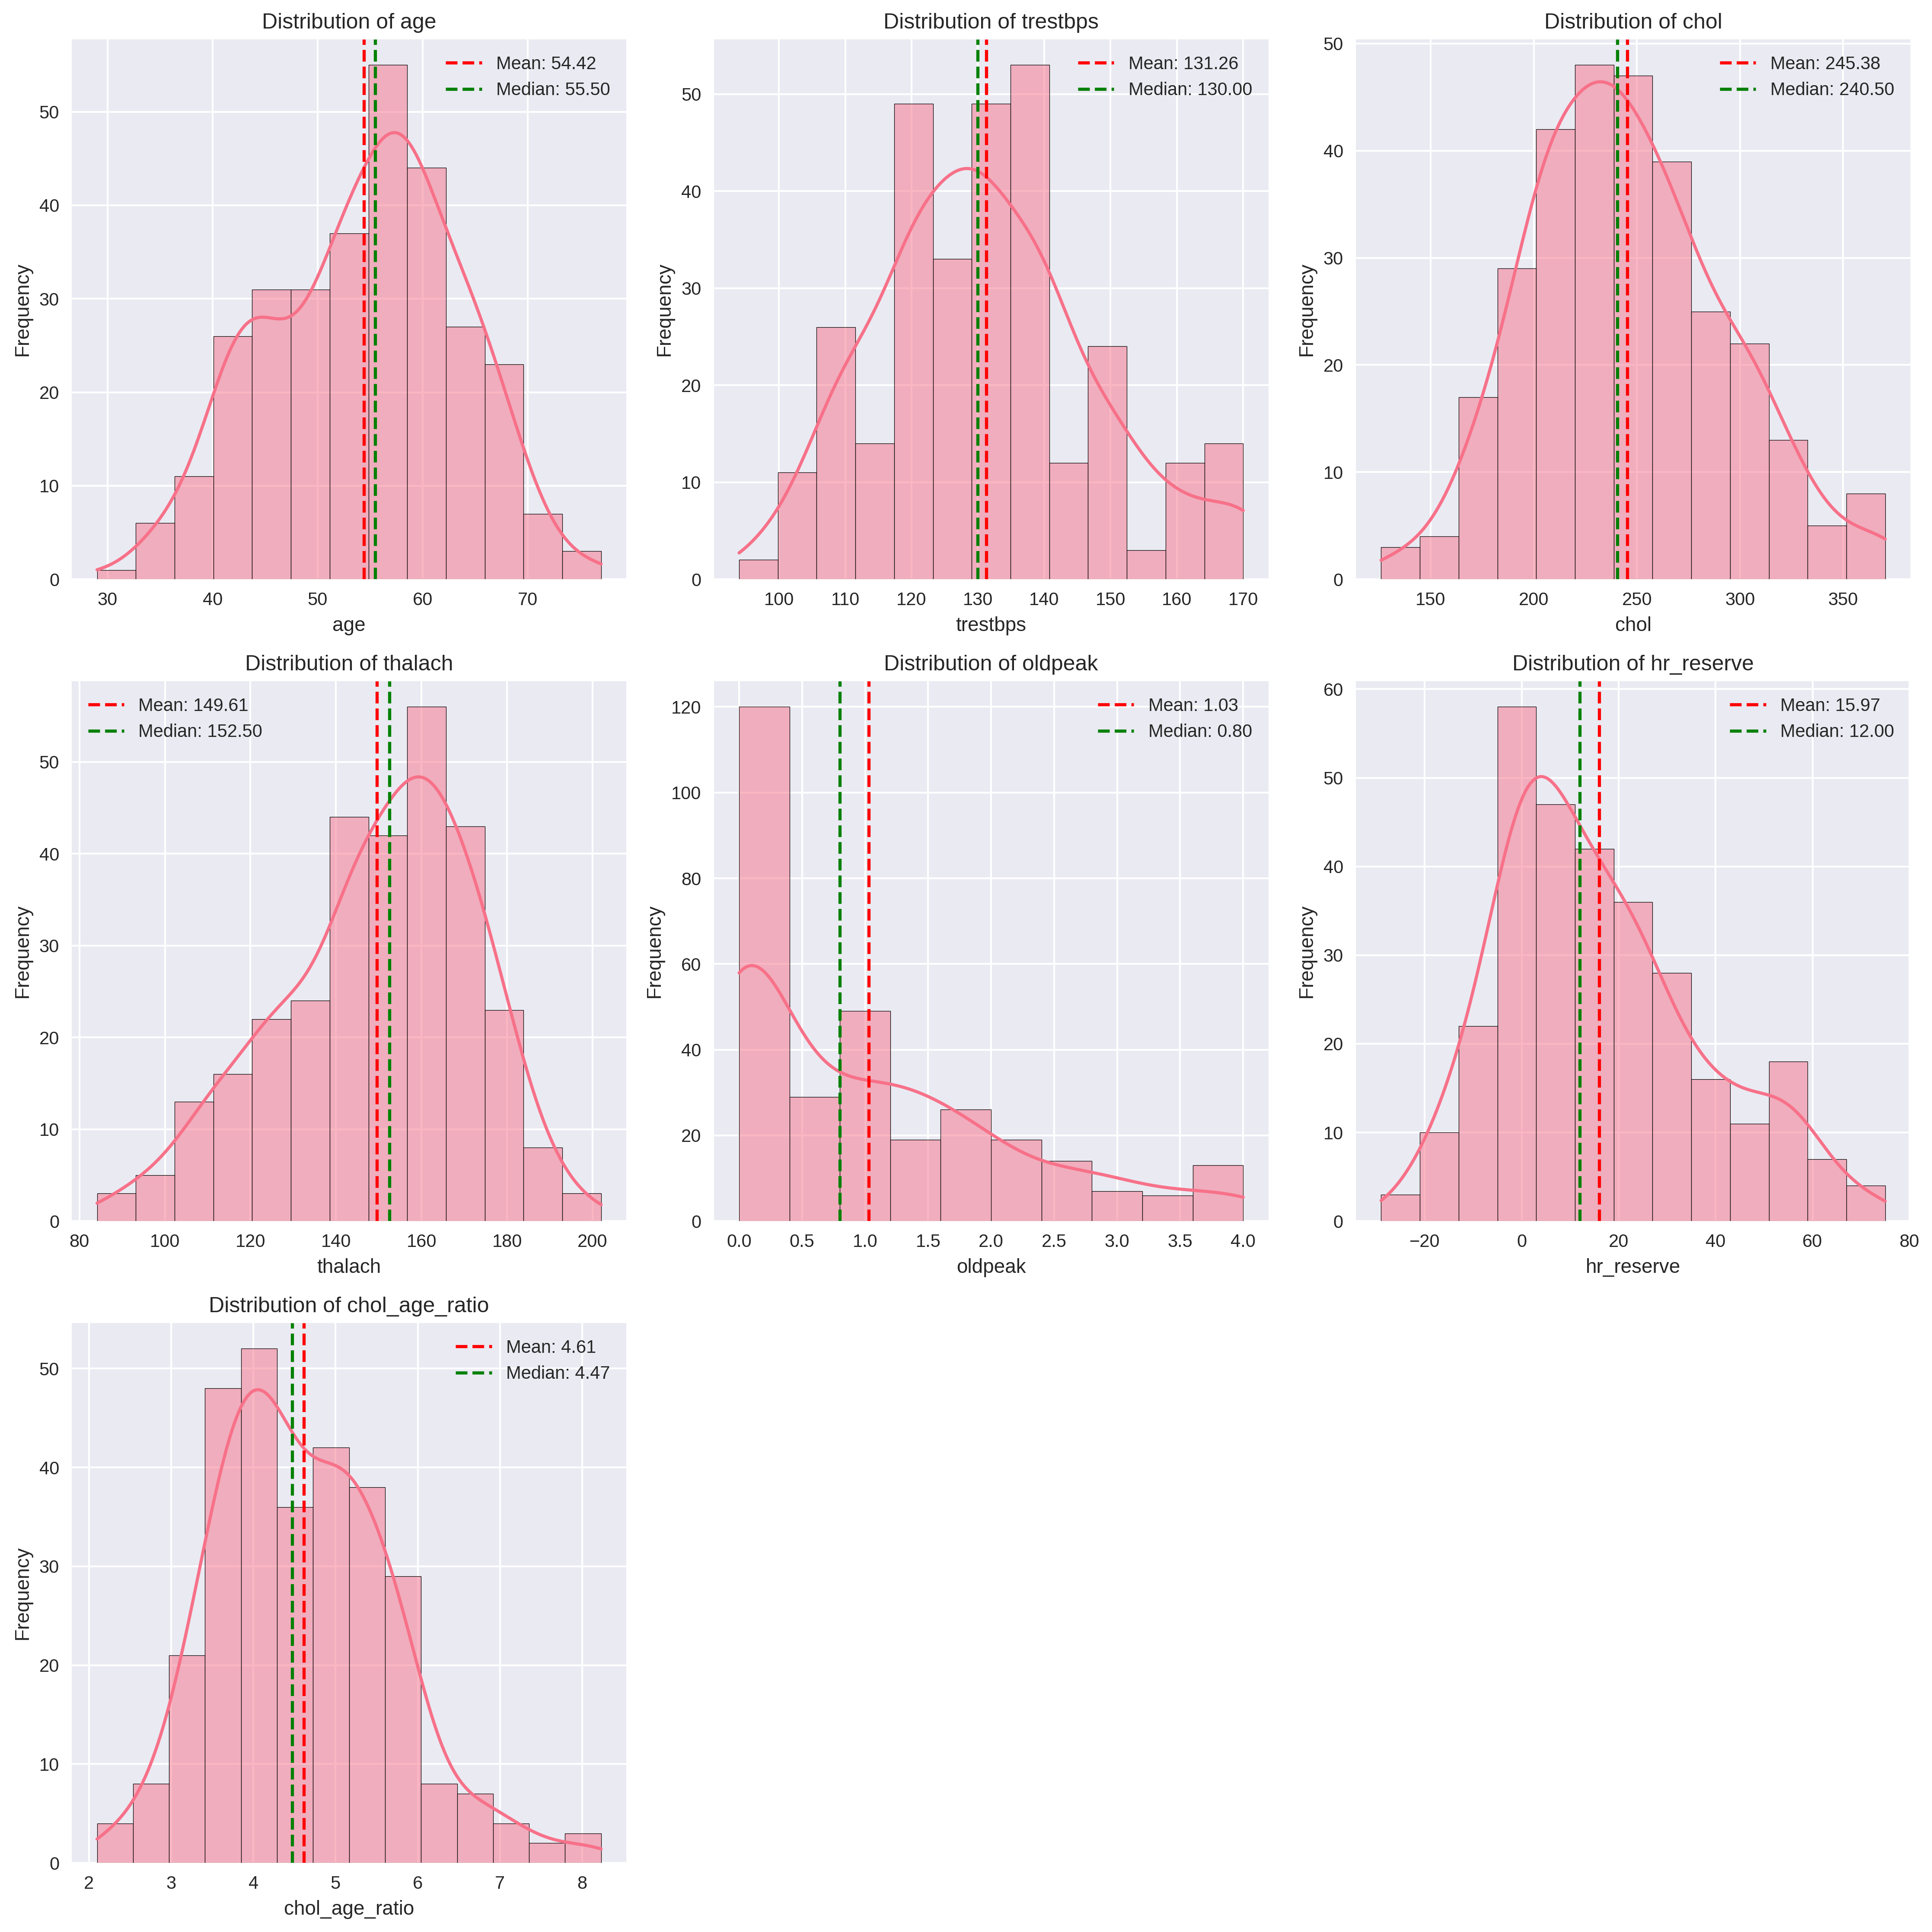

In [2]:
# 1. Distribution Plots
def create_distribution_plots(df: pd.DataFrame):
    """Create histogram + KDE plots for numeric columns."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        if idx < len(axes):
            data = df[col].dropna()
            sns.histplot(data, kde=True, ax=axes[idx])
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            axes[idx].axvline(data.mean(), color='red', linestyle='--',
                            label=f'Mean: {data.mean():.2f}')
            axes[idx].axvline(data.median(), color='green', linestyle='--',
                            label=f'Median: {data.median():.2f}')
            axes[idx].legend()
    
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig('../reports/figures/distribution_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

create_distribution_plots(df)

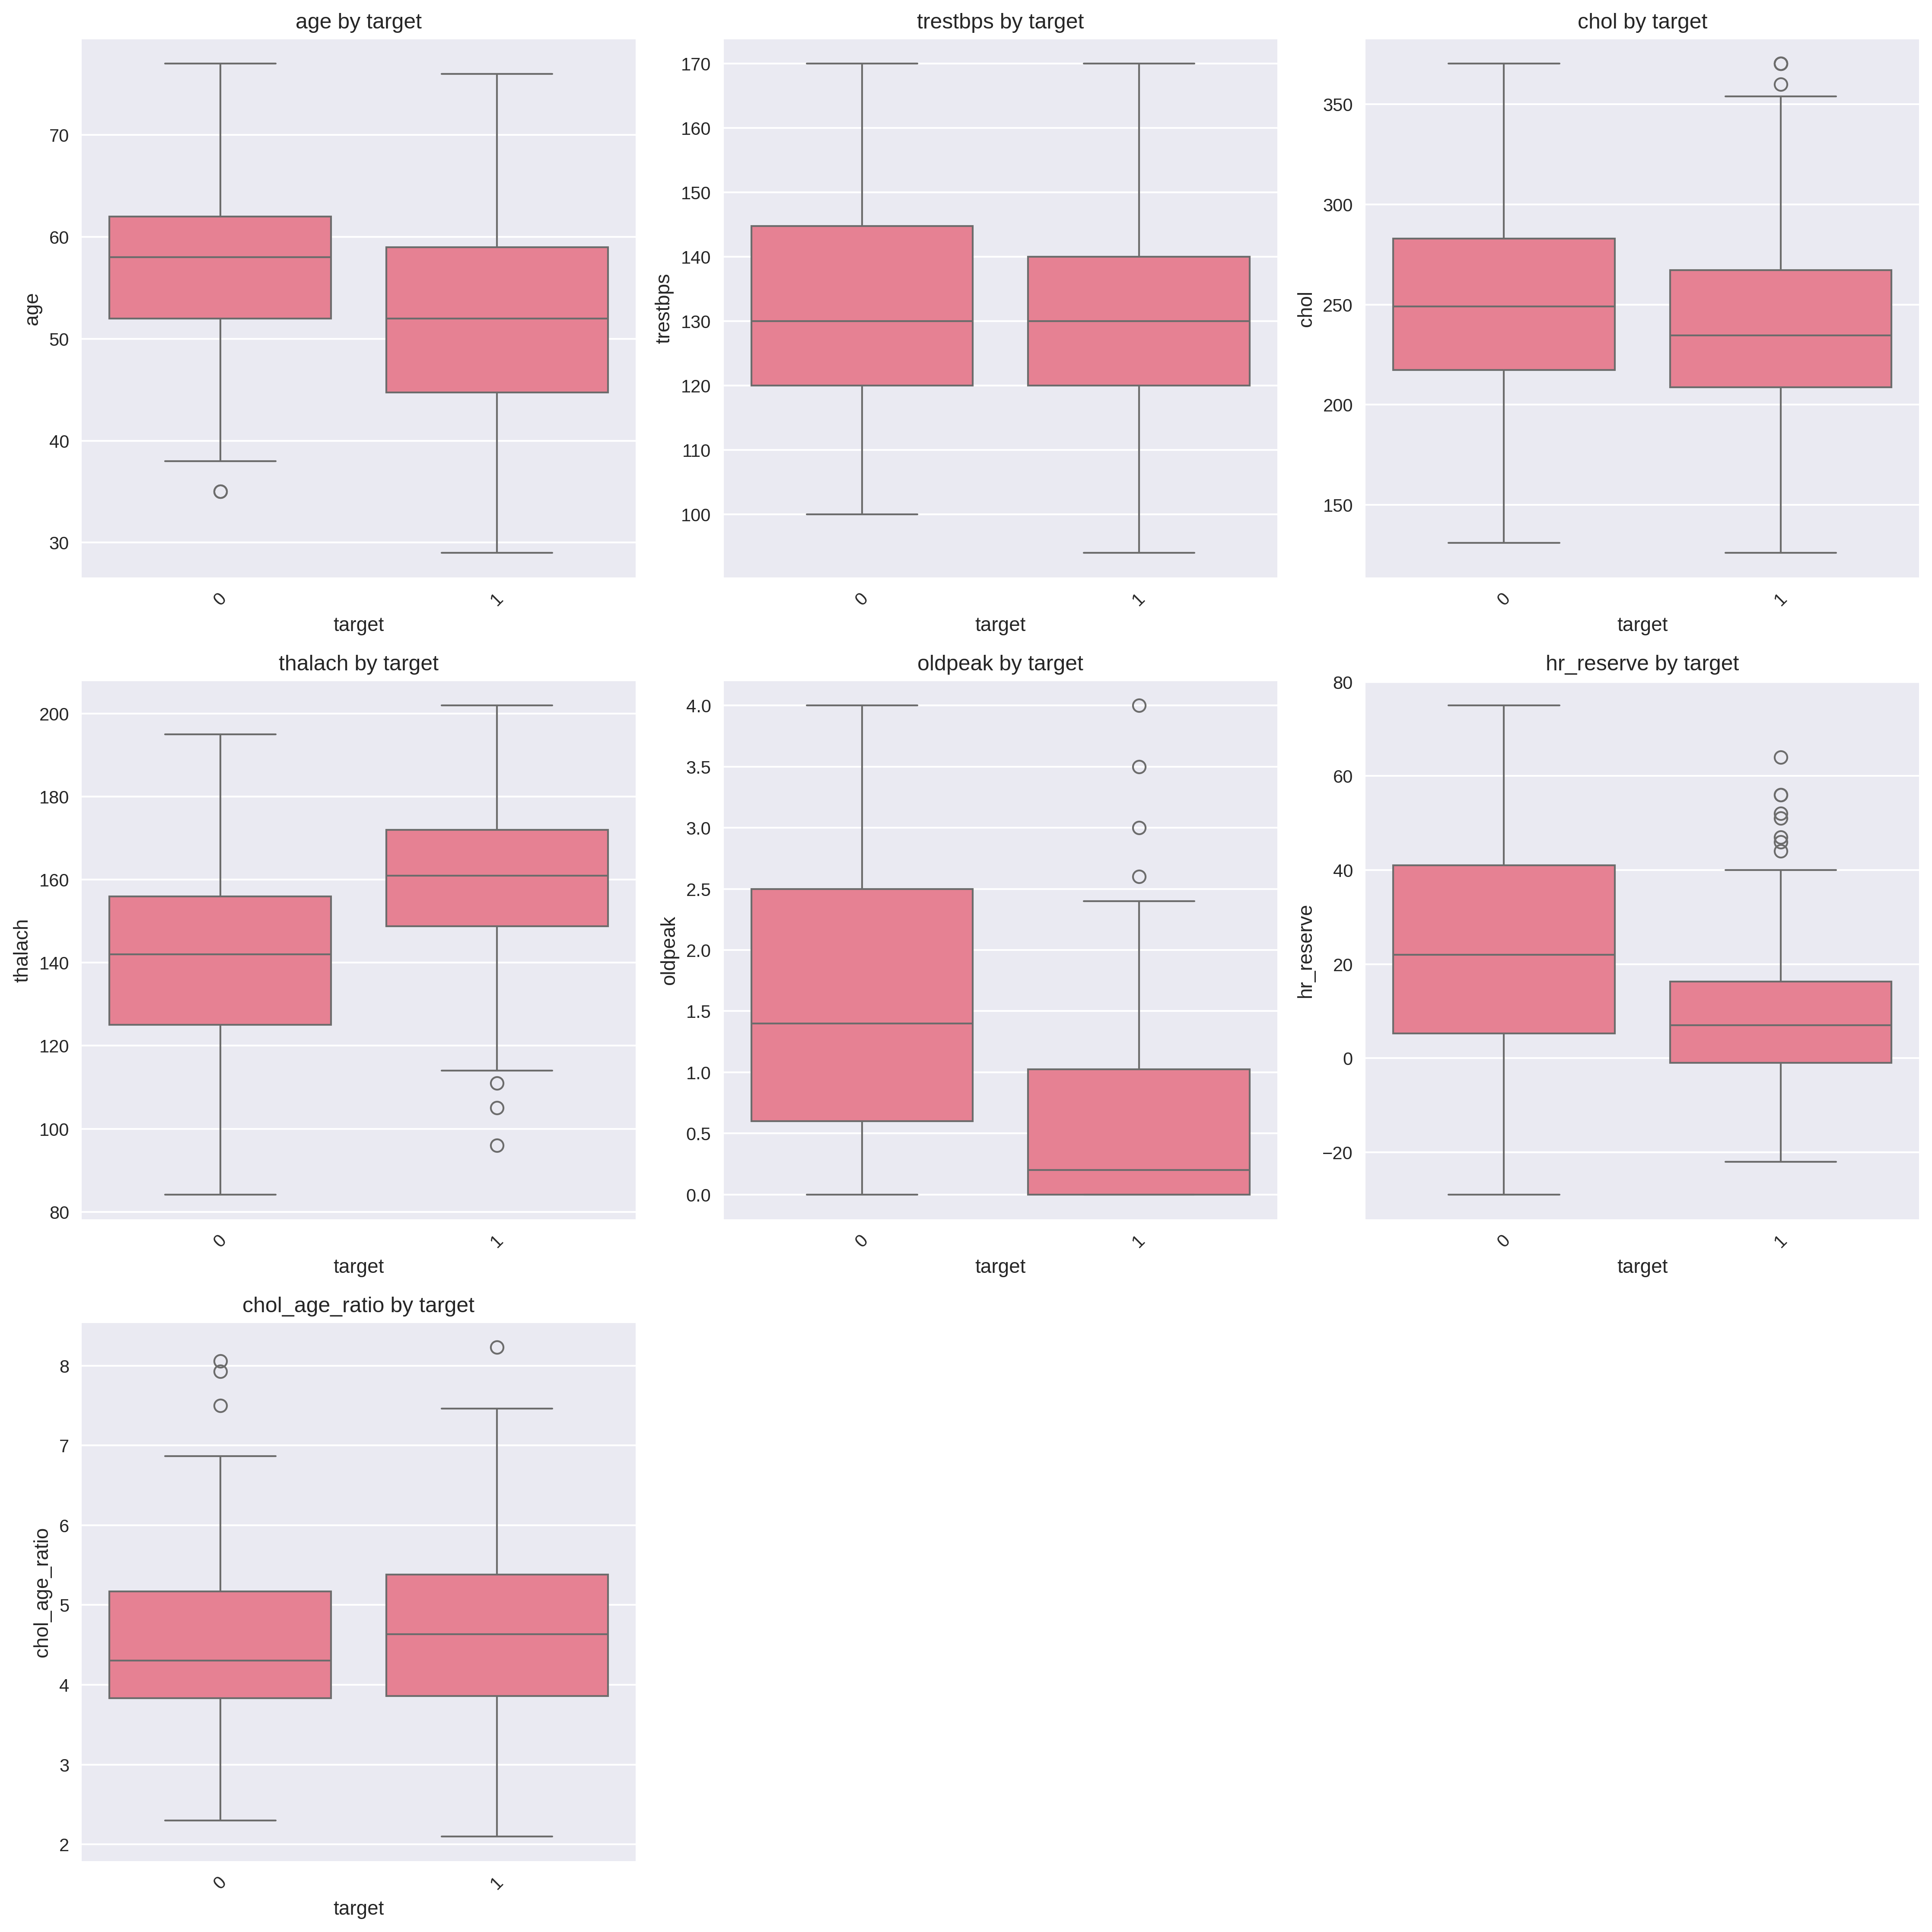

In [3]:
# 2. Box Plots (by category if available)
def create_boxplots(df: pd.DataFrame):
    """Create boxplots for numeric vs categorical variables."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns
    
    if len(categorical_cols) == 0:
        fig, axes = plt.subplots(1, min(4, len(numeric_cols)), figsize=(15, 5))
        if len(numeric_cols) == 1:
            axes = [axes]
        
        for idx, col in enumerate(numeric_cols[:4]):
            sns.violinplot(data=df[col].dropna(), ax=axes[idx])
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_ylabel(col)
        
        plt.tight_layout()
        plt.savefig('../reports/figures/violin_plots.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        cat_col = categorical_cols[0]
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        axes = axes.flatten()
        
        for idx, col in enumerate(numeric_cols):
            if idx < len(axes):
                sns.boxplot(data=df, x=cat_col, y=col, ax=axes[idx])
                axes[idx].set_title(f'{col} by {cat_col}')
                axes[idx].set_xlabel(cat_col)
                axes[idx].set_ylabel(col)
                axes[idx].tick_params(axis='x', rotation=45)
        
        for idx in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        plt.savefig('../reports/figures/boxplots.png', dpi=300, bbox_inches='tight')
        plt.show()

create_boxplots(df)

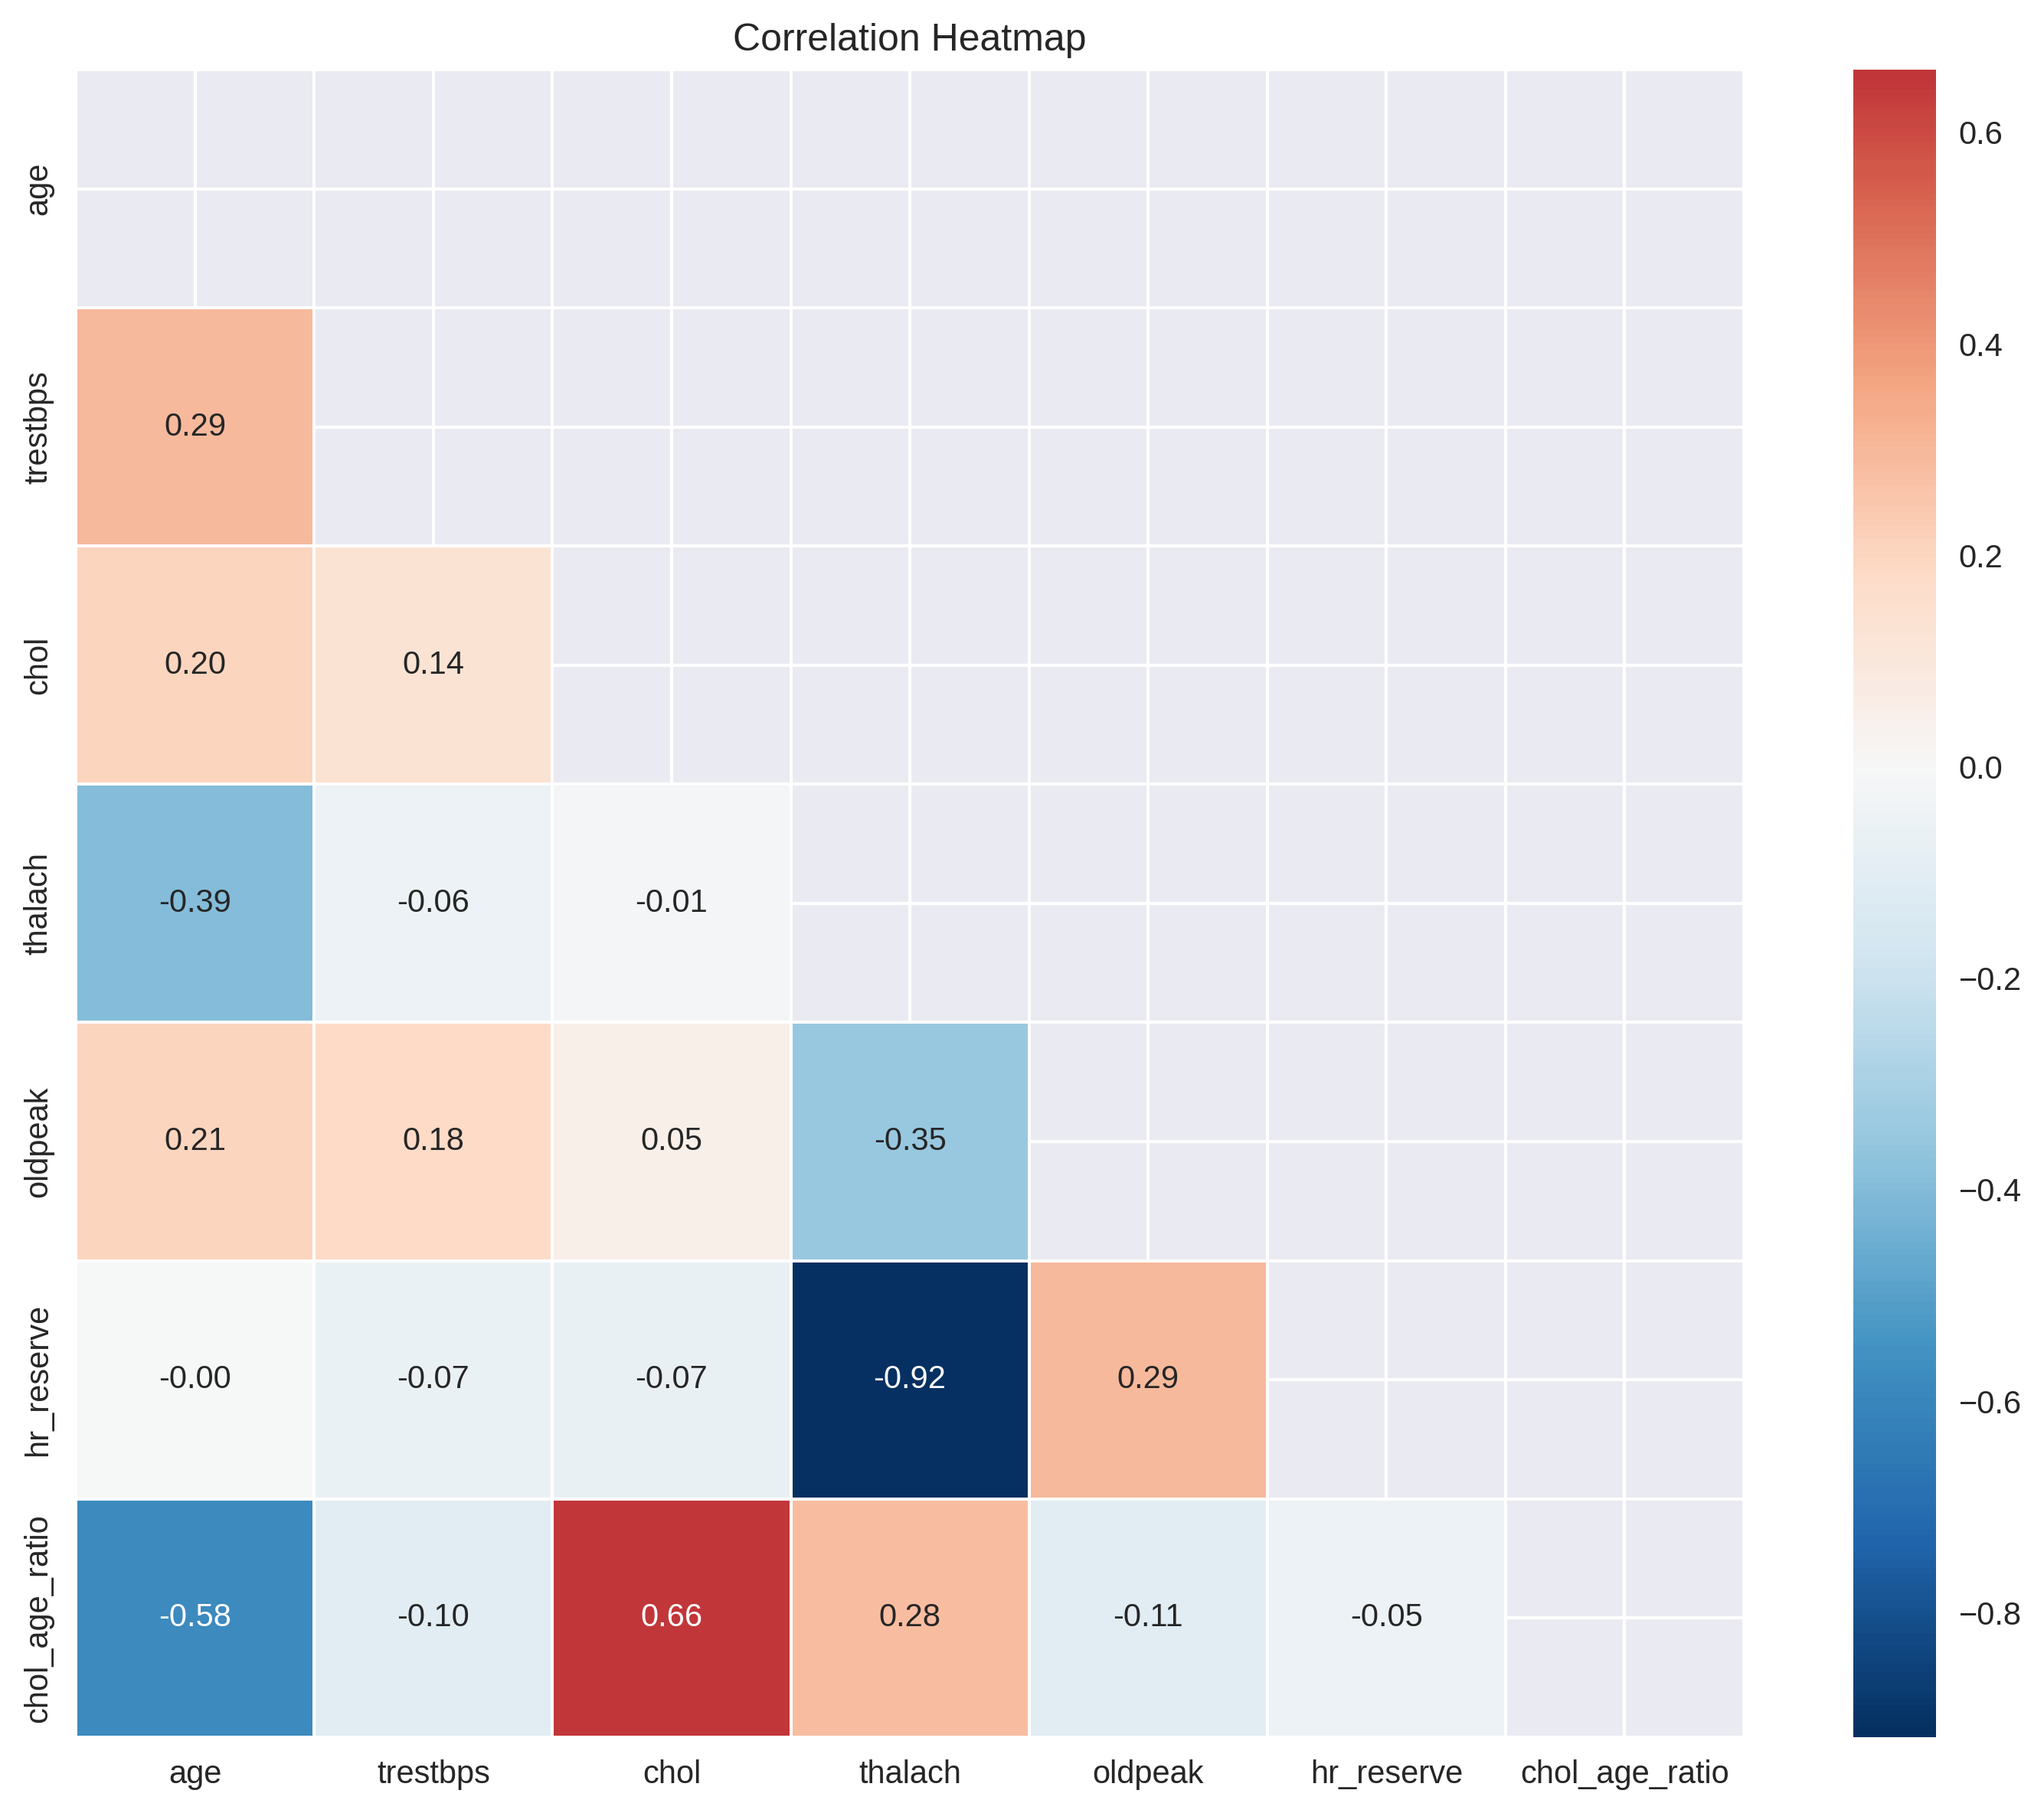

In [4]:
# 3. Correlation Heatmap
def create_correlation_heatmap(df: pd.DataFrame):
    """Create correlation heatmap."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    corr = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0,
                square=True, linewidths=0.5,
                ax=ax)
    
    ax.set_title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('../reports/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

create_correlation_heatmap(df)

In [5]:
# 4. Interactive Scatter Plot Matrix (Plotly)
def create_interactive_plots(df: pd.DataFrame):
    """Create interactive visualizations with Plotly."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    if len(numeric_cols) <= 5:
        fig = px.scatter_matrix(
            df,
            dimensions=numeric_cols,
            color=df.columns[0] if df.select_dtypes(include=['category', 'object']).shape[1] > 0 else None,
            title="Scatter Matrix"
        )
        fig.write_html('../reports/figures/scatter_matrix.html')
    
    if len(numeric_cols) >= 3:
        x_col, y_col, z_col = numeric_cols[:3]
        
        fig = px.scatter_3d(
            df,
            x=x_col,
            y=y_col,
            z=z_col,
            color=df.select_dtypes(include=['category', 'object']).columns[0]
                if df.select_dtypes(include=['category', 'object']).shape[1] > 0
                else None,
            title=f"3D Scatter: {x_col} vs {y_col} vs {z_col}",
            opacity=0.7,
            width=800,
            height=600
        )
        
        fig.update_layout(scene=dict(
            xaxis_title=x_col,
            yaxis_title=y_col,
            zaxis_title=z_col
        ))
        
        fig.write_html('../reports/figures/3d_scatter.html')
        fig.show()
    
    if len(numeric_cols) <= 4 and len(numeric_cols) > 1:
        fig = px.scatter_matrix(
            df,
            dimensions=numeric_cols[:4],
            color=df.select_dtypes(include=['category', 'object']).columns[0]
                if df.select_dtypes(include=['category', 'object']).shape[1] > 0
                else None,
            title="Interactive Pair Plot"
        )
        fig.write_html('../reports/figures/pair_plot.html')
        fig.show()

create_interactive_plots(df)

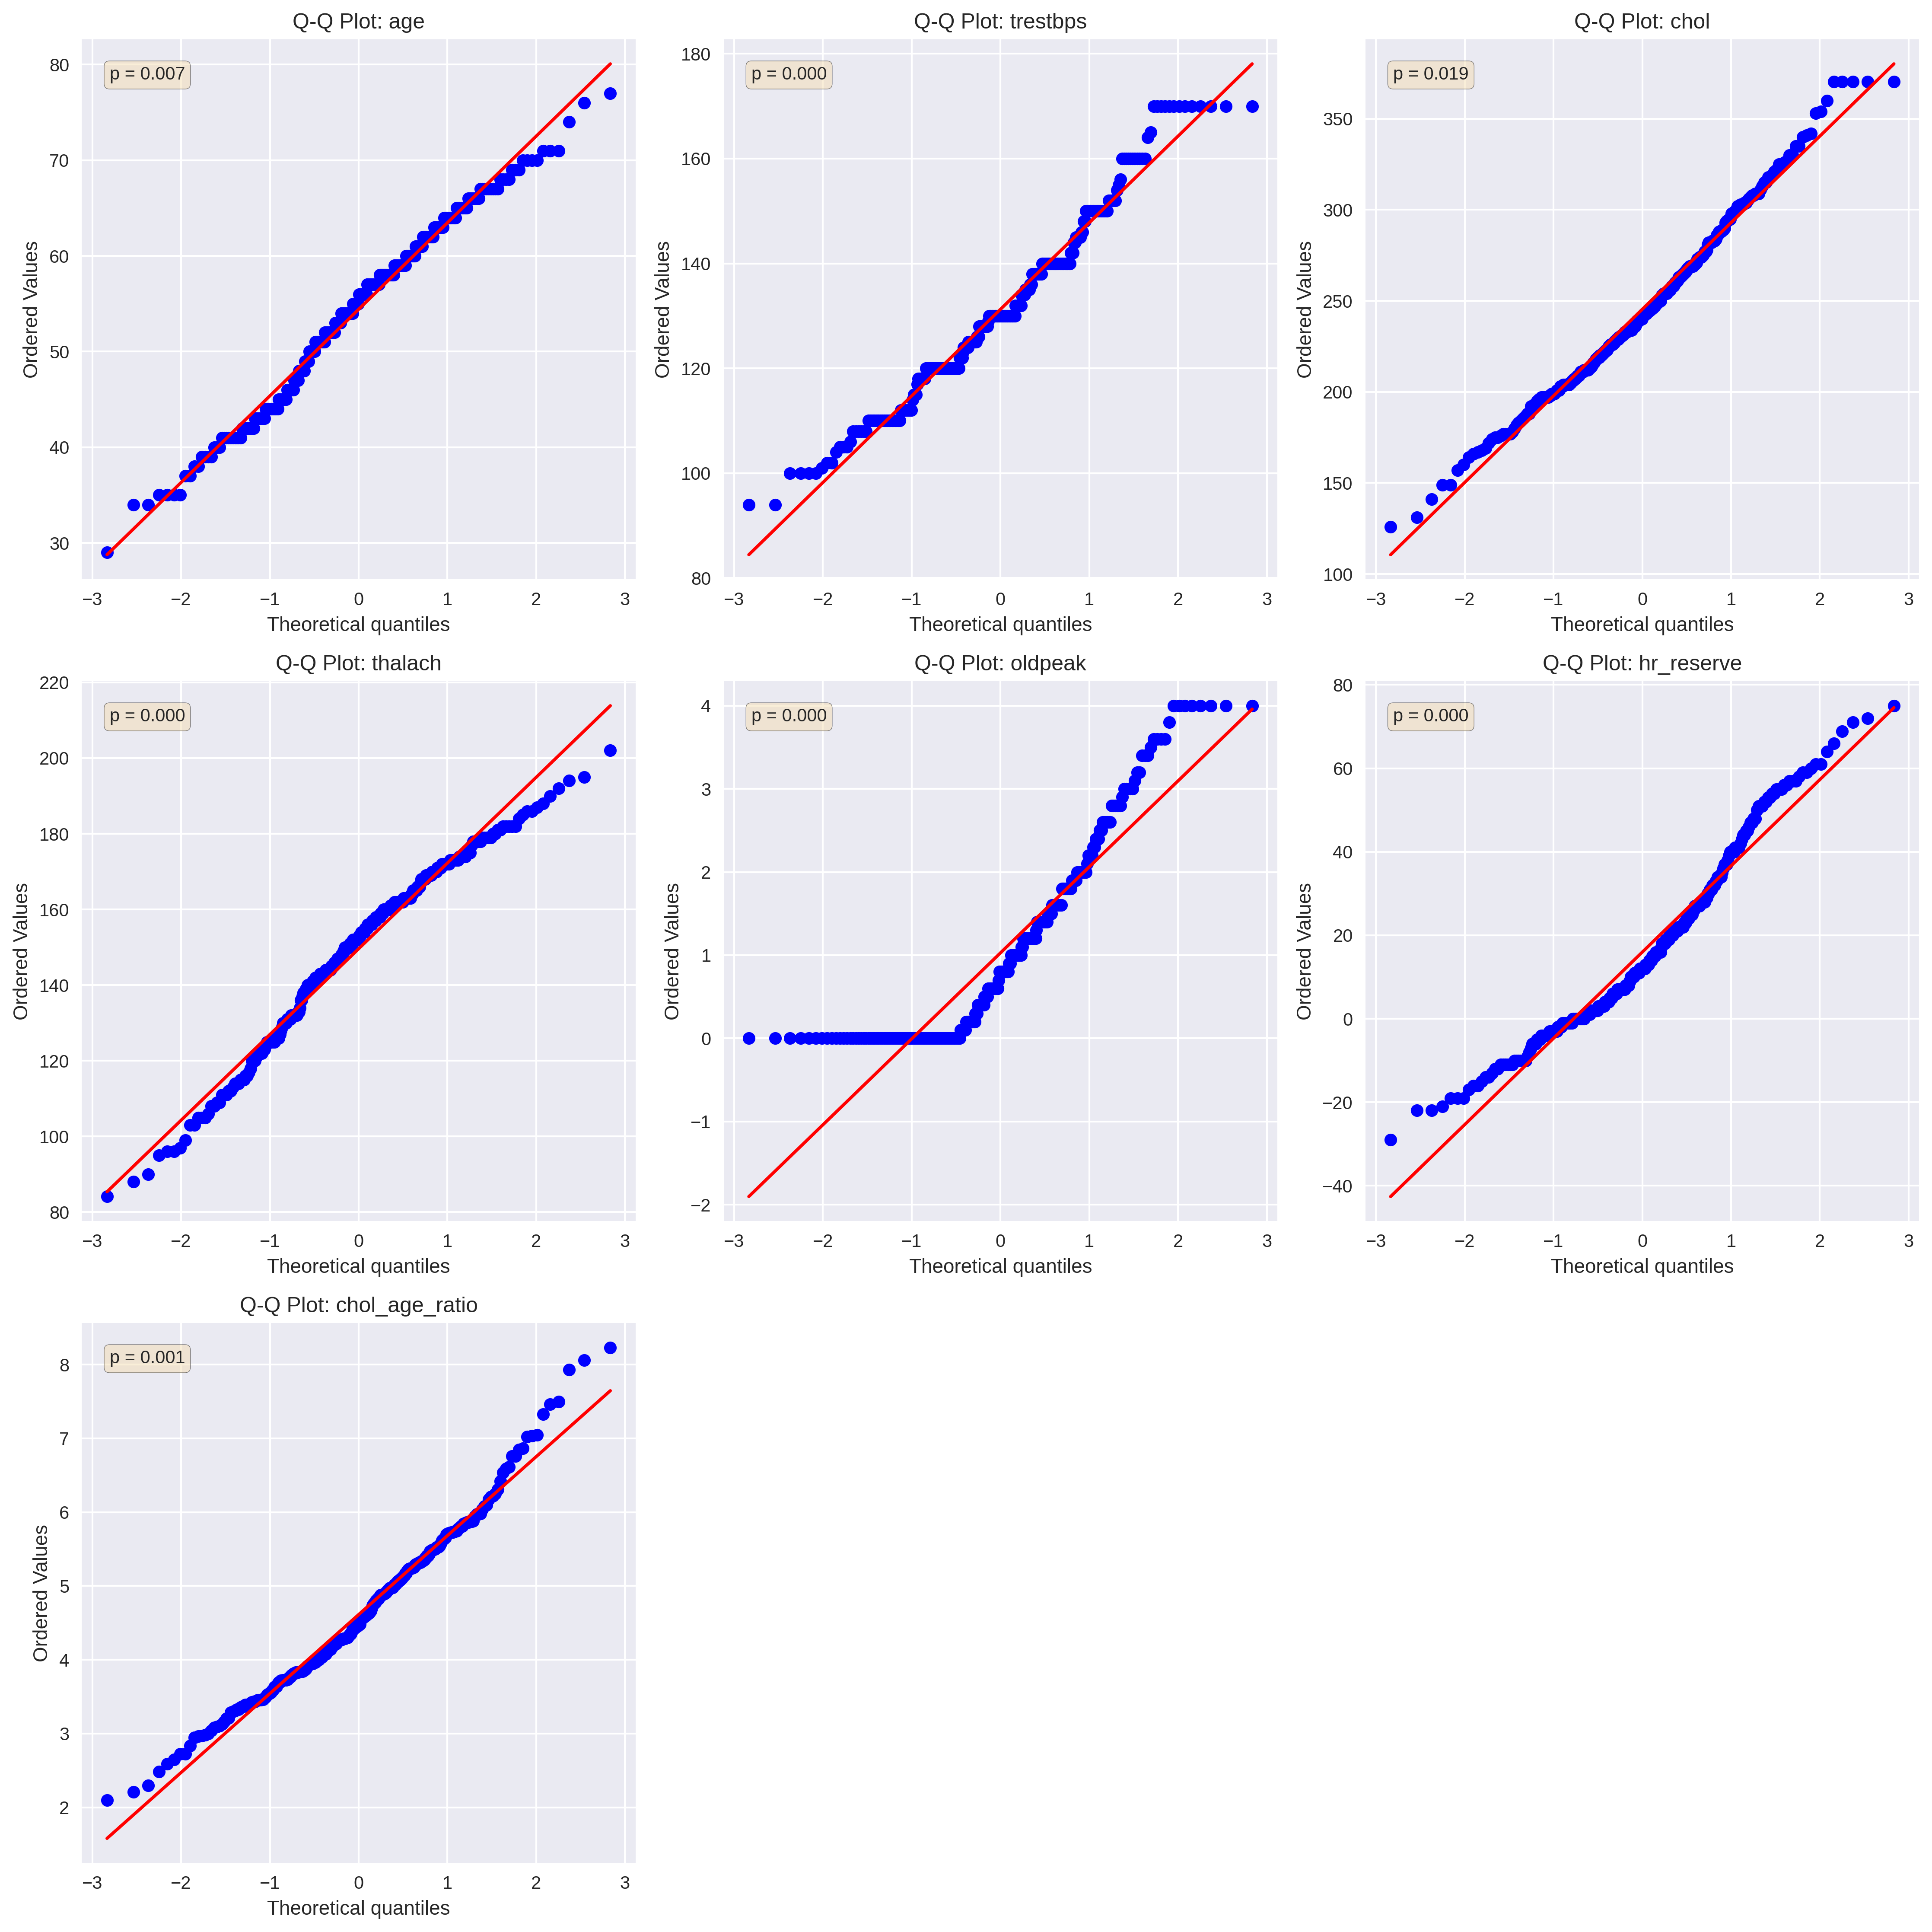

All visualizations created successfully!

In [6]:
# 5. Q-Q Plots for Normality Check
def create_qq_plots(df: pd.DataFrame):
    """Create Q-Q plots for numeric columns."""
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    from scipy import stats
    
    for idx, col in enumerate(numeric_cols):
        if idx < len(axes):
            data = df[col].dropna()
            stats.probplot(data, dist="norm", plot=axes[idx])
            axes[idx].set_title(f'Q-Q Plot: {col}')
            
            if len(data) > 3:
                _, p_value = stats.shapiro(data)
                axes[idx].text(0.05, 0.95, f'p = {p_value:.3f}',
                             transform=axes[idx].transAxes,
                             verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig('../reports/figures/qq_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

create_qq_plots(df)

print("All visualizations created successfully!")